# Model Explainability & Inference

In this notebook, we:
- Load the best model selected
- Tune the classification threshold to meet the business constraint (≤5% claimants accepted)
- Use SHAP to interpret model predictions and understand feature importance
- Model Inference 


In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import joblib
import shap

In [2]:
input_path = '../data/synth_insurance_data.csv'
input_model = "../models/xgboost_tuned_model.pkl"
image_output = '../outputs/images'

In [3]:
# Load best tuned XGBoost model
model = joblib.load(input_model)
print("Model loaded successfully.")

# Load the preprocessed dataset
data = pd.read_csv(input_path)
X = data.drop(columns='claim_status')
y = data['claim_status']

# Match column sanitization for XGBoost
X.columns = X.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# Split again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


Model loaded successfully.


In [4]:
# Get predicted probabilities
probs = model.predict_proba(X_test)[:, 1]

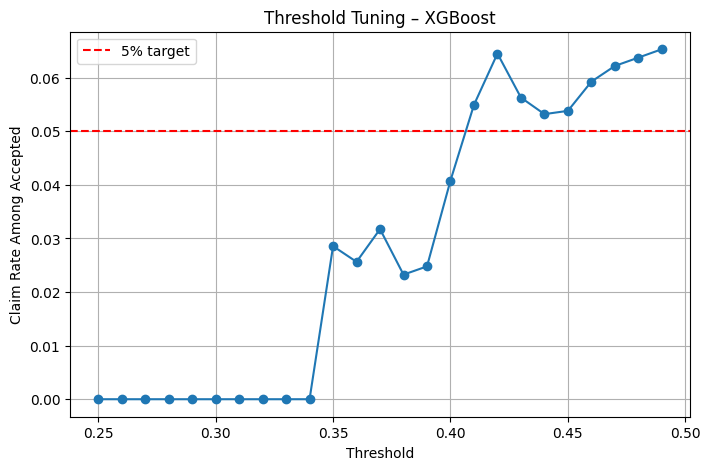

In [5]:
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.01, 0.5, 0.01)
claim_rates = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    accepted = preds == 0
    if accepted.sum() > 0:
        claim_rate = y_test[accepted].sum() / accepted.sum()
    else:
        claim_rate = np.nan
    claim_rates.append(claim_rate)

# Plot claim rate vs threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, claim_rates, marker='o')
plt.axhline(0.05, color='red', linestyle='--', label='5% target')
plt.xlabel("Threshold")
plt.ylabel("Claim Rate Among Accepted")
plt.title("Threshold Tuning – XGBoost")
plt.legend()
plt.grid()
plt.savefig(f"{image_output}/threshold_tuning_XGBoost.png")
plt.show()

In [6]:
final_threshold = 0.38
final_preds = (probs >= final_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(f"Final Threshold: {final_threshold}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_preds))

print("\nClassification Report:")
print(classification_report(y_test, final_preds))


Final Threshold: 0.38

Confusion Matrix:
[[  84 1754]
 [   2  164]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.05      0.09      1838
           1       0.09      0.99      0.16       166

    accuracy                           0.12      2004
   macro avg       0.53      0.52      0.12      2004
weighted avg       0.90      0.12      0.09      2004



## SHAP Explainability

We used SHAP to explain our XGBoost (Tuned) model.

- **Summary plot** shows the most impactful features globally.
- **Waterfall plot** reveals how features push individual predictions up/down.
- This improves transparency for business stakeholders.

Key drivers of risk: age, credit score, previous claims, health status.


In [7]:
# TreeExplainer is optimized for XGBoost, LightGBM, etc.
explainer = shap.TreeExplainer(model)


In [8]:
X_test_sample = X_test.sample(n=500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)


In [9]:
plt.figure()  # Start a new figure
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.savefig(f"{image_output}/shap_summary_plot.png", dpi=300)
plt.close()

In [10]:
plt.figure()  # Start a fresh figure
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(f"{image_output}/shap_features_plot.png", dpi=300)
plt.close()

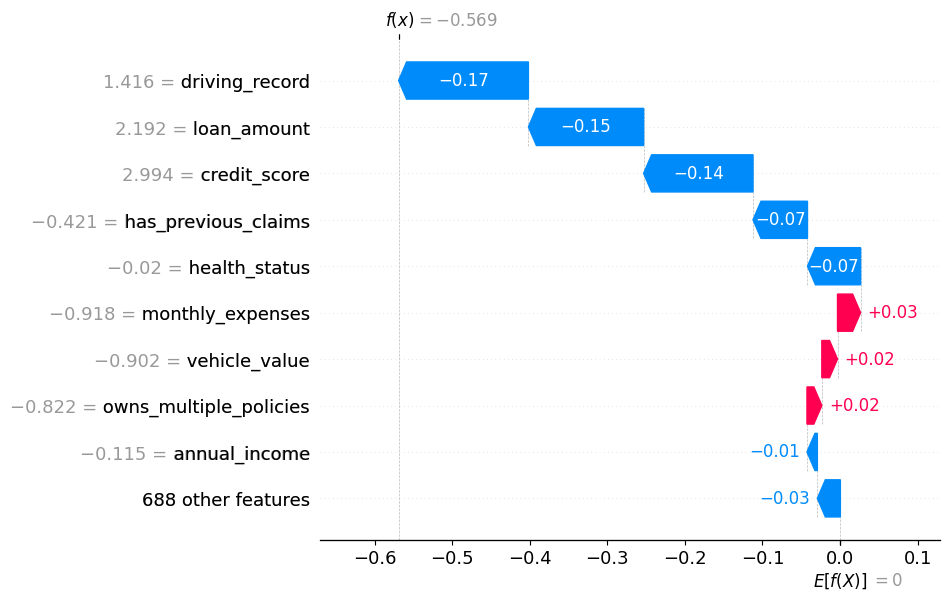

In [11]:
# Choose a row
i = 0  # pick another index for a different customer
shap.plots.waterfall(shap.Explanation(values=shap_values[i],
                                       base_values=explainer.expected_value,
                                       data=X_test_sample.iloc[i]))

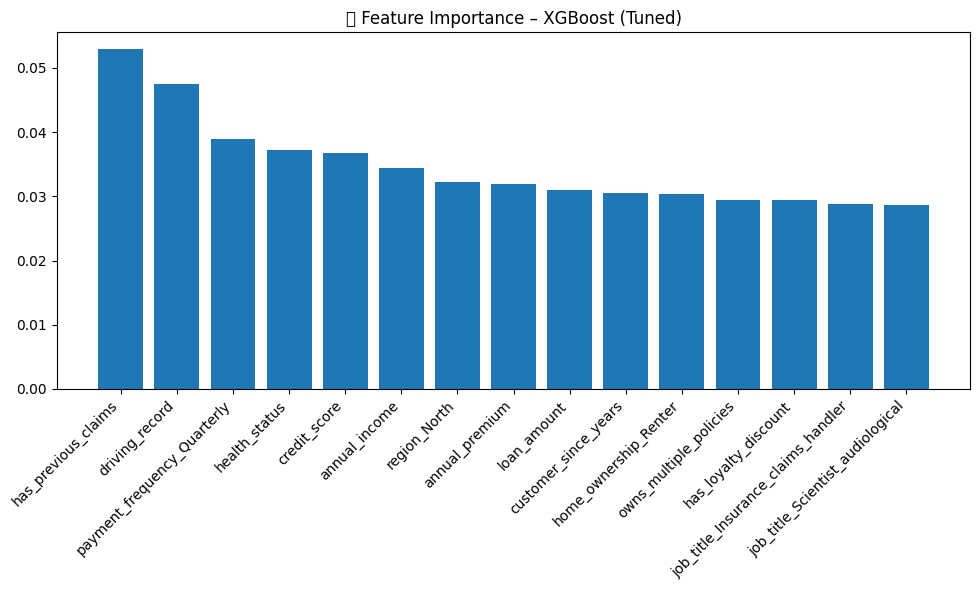

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance and names
importances = model.feature_importances_
feature_names = X_train.columns

# Sort
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.title("📊 Feature Importance – XGBoost (Tuned)")
plt.bar(range(15), importances[indices[:15]], align='center')
plt.xticks(range(15), [feature_names[i] for i in indices[:15]], rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{image_output}/tuned_feature_importance.png")
plt.show()

## Model Inference

In [13]:
X = data.drop(columns='claim_status', errors='ignore')

# Match column format (especially after one-hot encoding)
X.columns = X.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

sample = X.tail(5)

# --- Predict probabilities and labels ---
probs = model.predict_proba(sample)[:, 1]
threshold = 0.38  # From earlier threshold tuning
preds = (probs >= threshold).astype(int)

result_df = sample.copy()
result_df['claim_probability'] = probs
result_df['prediction'] = preds

print(result_df[['claim_probability', 'prediction']])

       claim_probability  prediction
10011           0.594997           1
10012           0.464889           1
10013           0.526916           1
10014           0.549243           1
10015           0.538087           1
